# L4 - Evaluate

Decoding is tuned on **validation**. Test is decoded **once**, at the end, with
whatever validation chose. Touching test twice turns it into a second
validation set and the number stops meaning anything.

Reported against the copy baseline, never alone.

In [1]:
# Find the repo by walking up from wherever the kernel started, and put it on
# sys.path. Self-contained: no setup cell needed, and a notebook's working
# directory is not reliably its own directory.
import os, sys

ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "src")) and ROOT != os.path.dirname(ROOT):
    ROOT = os.path.dirname(ROOT)
if not os.path.isdir(os.path.join(ROOT, "src")):
    raise RuntimeError(f"no src/ found above {os.getcwd()}")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import json
import time

import matplotlib.pyplot as plt
import torch

from src.config import get_device
from src.dataset import load_split
from src.evaluate import bleu, chrf, copy_baseline
from src.inference import translate_corpus
from src.spm_tokenizer import SPMTokenizer
from src.train import load_checkpoint

%matplotlib inline
DATA = os.path.join(ROOT, "data")
CHECKPOINT = os.path.join(ROOT, "checkpoints", "latin.pt")
OUTPUTS = os.path.join(ROOT, "outputs")
os.makedirs(OUTPUTS, exist_ok=True)
MAX_LEN, GEN_CAP = 128, 200

device = get_device()
tokenizer = SPMTokenizer(os.path.join(DATA, "spm8k.model"))

valid_la, valid_en = load_split(DATA, "valid")
test_la, test_en = load_split(DATA, "test")
test_src = open(os.path.join(DATA, "test.src"), encoding="utf-8").read().splitlines()

valid_baseline = copy_baseline(valid_la, valid_en)
test_baseline = copy_baseline(test_la, test_en)

model, meta = load_checkpoint(CHECKPOINT, device=device)
print("root:", ROOT, "| device:", device)
print(f"checkpoint: epoch {meta['epoch']}, valid BLEU {meta['score']:.2f}")
print(f"valid {len(valid_la):,} | test {len(test_la):,}")
print(f"copy baseline   valid {valid_baseline:.2f}   test {test_baseline:.2f}")

root: c:\Games\Codes\Python\Projects\2.transformer-from-scratch | device: cuda
checkpoint: epoch 60, valid BLEU 18.48
valid 3,003 | test 3,003
copy baseline   valid 0.27   test 0.31


## Tuning on validation

Two sweeps rather than a grid: beam size at a fixed penalty, then the penalty
at the winning beam. `amp=True` here for speed; the test number below is
decoded in fp32.

In [2]:
# Sized from measurement, not guesswork: a batch of 24 peaked at 0.44 GB of
# 4.29, so the batches were far too small and each decode step ran at a few
# percent utilisation. Beam search holds batch x beam sequences at once, so the
# batch shrinks as the beam grows and the product stays put.
BEAMS_AT_ONCE = 128

# Nine decodes of all 3,003 validation sentences is most of an hour on a laptop
# GPU. 500 is enough to rank beams and penalties against each other, and the
# test number below is still every sentence, decoded once.
TUNE_N = 500
tune_la, tune_en = valid_la[:TUNE_N], valid_en[:TUNE_N]


def decode(source, beam, alpha, amp=True):
    """Decode, halving the batch and retrying if CUDA runs out of memory.

    fp32 holds about twice the activations of fp16, so the budget halves when
    amp is off - which is the case for the reported test decode.
    """
    batch = max(2, (BEAMS_AT_ONCE if amp else BEAMS_AT_ONCE // 2) // beam)
    while True:
        try:
            return translate_corpus(model, source, tokenizer, device,
                                    batch_size=batch, beam_size=beam,
                                    length_penalty=alpha, src_max_len=MAX_LEN,
                                    max_len=GEN_CAP, amp=amp)
        except torch.cuda.OutOfMemoryError:
            if batch <= 2:
                raise
            torch.cuda.empty_cache()
            batch //= 2
            print(f"  out of memory - retrying at batch {batch}", flush=True)


def score(beam, alpha):
    started = time.time()
    return bleu(decode(tune_la, beam, alpha), tune_en), time.time() - started


beam_results = {}
for beam in (1, 4, 8):
    beam_results[beam], secs = score(beam, 1.0)
    print(f"beam {beam}  alpha 1.0   BLEU {beam_results[beam]:6.2f}   "
          f"({secs/60:.1f} min)", flush=True)

best_beam = max(beam_results, key=beam_results.get)
print(f"\nbest beam {best_beam}")

beam 1  alpha 1.0   BLEU  17.65   (4.9 min)
beam 4  alpha 1.0   BLEU  18.31   (1.2 min)
beam 8  alpha 1.0   BLEU  18.33   (2.6 min)

best beam 8


In [3]:
alpha_results = {1.0: beam_results[best_beam]}
for alpha in (0.6, 1.5):
    alpha_results[alpha], secs = score(best_beam, alpha)
    print(f"beam {best_beam}  alpha {alpha:3.1f}   "
          f"BLEU {alpha_results[alpha]:6.2f}   ({secs/60:.1f} min)", flush=True)

best_alpha = max(alpha_results, key=alpha_results.get)
print(f"\nchosen: beam {best_beam}, alpha {best_alpha}  ->  "
      f"BLEU {alpha_results[best_alpha]:.2f} on {TUNE_N} validation sentences "
      f"(baseline {valid_baseline:.2f})")

beam 8  alpha 0.6   BLEU  18.15   (2.6 min)
beam 8  alpha 1.5   BLEU  18.49   (2.5 min)

chosen: beam 8, alpha 1.5  ->  BLEU 18.49 on 500 validation sentences (baseline 0.27)


## Test - decoded once

fp32, so the number is exactly reproducible.

In [4]:
started = time.time()
test_hyp = decode(test_la, best_beam, best_alpha, amp=False)
print(f"decoded {len(test_hyp):,} sentences in {(time.time()-started)/60:.1f} min\n")

test_bleu = bleu(test_hyp, test_en)
test_chrf = chrf(test_hyp, test_en)
base_chrf = chrf(test_la, test_en)

print(f"{'':8} {'BLEU':>8} {'chrF':>8}")
print(f"{'copy':8} {test_baseline:8.2f} {base_chrf:8.2f}")
print(f"{'model':8} {test_bleu:8.2f} {test_chrf:8.2f}")
print(f"\n{test_bleu/test_baseline:.0f}x the baseline")

decoded 3,003 sentences in 26.9 min

             BLEU     chrF
copy         0.31    19.74
model       18.87    42.78

61x the baseline


## Where it works

By source length, and Vulgate against everything else. The second is the
interesting one - a third of the corpus is formulaic scripture and the rest is
real prose.

In [5]:
lengths = [len(tokenizer.encode(line)) for line in test_la]
buckets = [("1-20", 1, 20), ("21-35", 21, 35), ("36-55", 36, 55), ("56+", 56, 10**6)]

def subset(idx):
    h = [test_hyp[i] for i in idx]
    r = [test_en[i] for i in idx]
    return bleu([test_la[i] for i in idx], r), bleu(h, r), chrf(h, r)

print(f"{'src tokens':>12} {'n':>6} {'copy':>7} {'BLEU':>7} {'chrF':>7}")
length_rows = []
for name, lo, hi in buckets:
    idx = [i for i, n in enumerate(lengths) if lo <= n <= hi]
    if not idx:
        continue
    base, b, c = subset(idx)
    length_rows.append((name, len(idx), base, b, c))
    print(f"{name:>12} {len(idx):>6} {base:7.2f} {b:7.2f} {c:7.2f}")

  src tokens      n    copy    BLEU    chrF
        1-20    729    0.74   26.01   46.38
       21-35   1019    0.39   25.89   47.13
       36-55    733    0.11   18.84   42.90
         56+    522    0.17   11.04   38.76


In [6]:
vulgate = [i for i, s in enumerate(test_src) if s == "Vulgate_Bible"]
classical = [i for i, s in enumerate(test_src) if s != "Vulgate_Bible"]

print(f"{'':12} {'n':>6} {'copy':>7} {'BLEU':>7} {'chrF':>7}")
split_rows = []
for name, idx in (("Vulgate", vulgate), ("classical", classical)):
    base, b, c = subset(idx)
    split_rows.append((name, len(idx), base, b, c))
    print(f"{name:12} {len(idx):>6} {base:7.2f} {b:7.2f} {c:7.2f}")

print(f"\n{len(set(test_src))} distinct works in test; "
      f"{len(vulgate)/len(test_src):.1%} Vulgate")

                  n    copy    BLEU    chrF
Vulgate         984    0.45   40.37   61.00
classical      2019    0.19   10.36   37.16

252 distinct works in test; 32.8% Vulgate


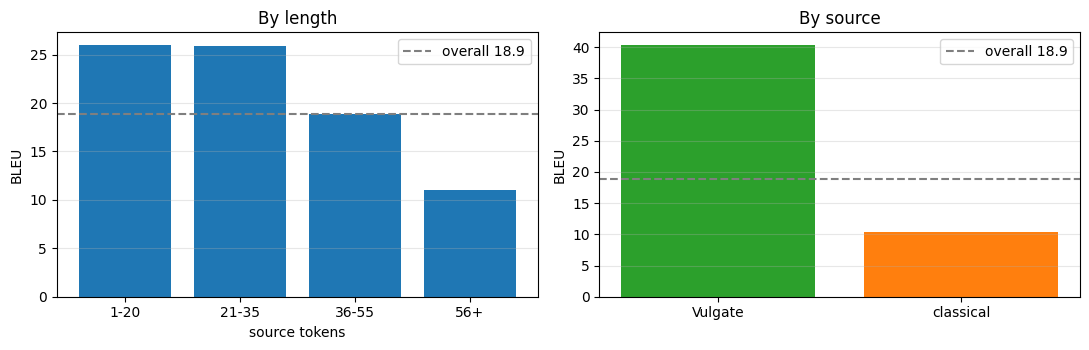

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar([r[0] for r in length_rows], [r[3] for r in length_rows], color="tab:blue")
axes[0].set_xlabel("source tokens"); axes[0].set_ylabel("BLEU")
axes[0].set_title("By length")

axes[1].bar([r[0] for r in split_rows], [r[3] for r in split_rows],
            color=["tab:green", "tab:orange"])
axes[1].set_ylabel("BLEU"); axes[1].set_title("By source")

for ax in axes:
    ax.axhline(test_bleu, color="tab:gray", ls="--", label=f"overall {test_bleu:.1f}")
    ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "test_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save

The predictions are the one artefact here that cannot be regenerated without
the checkpoint.

In [8]:
results = {
    "checkpoint": {"epoch": meta["epoch"], "valid_bleu": meta["score"]},
    "decoding": {"beam": best_beam, "alpha": best_alpha, "tuned_on": TUNE_N,
                 "beam_sweep": beam_results, "alpha_sweep": alpha_results},
    "test": {"n": len(test_la), "bleu": test_bleu, "chrf": test_chrf,
             "copy_bleu": test_baseline, "copy_chrf": base_chrf},
    "by_length": [dict(zip(("bucket", "n", "copy", "bleu", "chrf"), r))
                  for r in length_rows],
    "by_source": [dict(zip(("split", "n", "copy", "bleu", "chrf"), r))
                  for r in split_rows],
}
with open(os.path.join(OUTPUTS, "test_results.json"), "w") as f:
    json.dump(results, f, indent=1)

with open(os.path.join(OUTPUTS, "test_predictions.en"), "w", encoding="utf-8") as f:
    f.write("\n".join(test_hyp) + "\n")

lines = [
    "# Latin -> English, test results", "",
    f"Decoded once with beam {best_beam}, length penalty {best_alpha}, chosen on "
    f"{TUNE_N} validation sentences. Checkpoint from epoch {meta['epoch']}.", "",
    "| | BLEU | chrF |", "|---|---|---|",
    f"| copy baseline | {test_baseline:.2f} | {base_chrf:.2f} |",
    f"| model | {test_bleu:.2f} | {test_chrf:.2f} |", "",
    "| source tokens | n | copy | BLEU | chrF |", "|---|---|---|---|---|",
    *[f"| {n} | {c} | {base:.2f} | {b:.2f} | {ch:.2f} |"
      for n, c, base, b, ch in length_rows], "",
    "| split | n | copy | BLEU | chrF |", "|---|---|---|---|---|",
    *[f"| {n} | {c} | {base:.2f} | {b:.2f} | {ch:.2f} |"
      for n, c, base, b, ch in split_rows], "",
]
with open(os.path.join(OUTPUTS, "results.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

for name in sorted(os.listdir(OUTPUTS)):
    print(f"  {name:<28} {os.path.getsize(os.path.join(OUTPUTS, name))/1024:8.1f} KB")

  Training&ValidationCurves.png     75.9 KB
  results.md                        0.6 KB
  test_breakdown.png               34.3 KB
  test_predictions.en             493.0 KB
  test_results.json                 1.4 KB


## Read the output

In [9]:
short_vulgate = sorted(vulgate, key=lambda i: lengths[i])[:3]
long_classical = sorted(classical, key=lambda i: lengths[i])[-3:]

for label, idx in (("VULGATE", short_vulgate), ("CLASSICAL, longest", long_classical)):
    print(f"----- {label} -----")
    for i in idx:
        print("LA  :", test_la[i][:110])
        print("PRED:", test_hyp[i][:110])
        print("REF :", test_en[i][:110])
        print()

----- VULGATE -----
LA  : non occides
PRED: Thou shalt not kill.
REF : Thou shalt not kill.

LA  : qui dixit ad eum
PRED: And he said to him:
REF : And the Lord said to him:

LA  : responderuntque filii Heth
PRED: And the children of Heth answered:
REF : The children of Heth answered, saying:

----- CLASSICAL, longest -----
LA  : tum regia Iuno acta furore gravi: quid me alta silentia cogis rumpere et obductum verbis vulgare dolorem? Aene
PRED: Then the royal queen Juno was troubled with bitter fury: Why do you forced me to break out the deep silence an
REF : Then royal Juno, spurred by fierce frenzy: Why do you force me to break my deepsilence and publish to the worl

LA  : Nam quo sordidius et abiectius nati sunt quoque notabilior paupertas et angustiae rerum nascentes eos circumst
PRED: For as soon as they are born, the poorer poverty and narrower than the narrowness of the state are surrounded 
REF : The meaner and the more humble was the origin of those two men, and the more notor

## Done

Decoding chosen on validation, test scored once, reported beside the baseline.